In [1]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np

from src.preprocess import preprocess_df
from src.network_model import NetworkModel
from src.analyze_cic_ids import nre_classification, flow_based_classification
from src.classification_tools import plot_roc_curves

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Monday-WorkingHours.pcap_ISCX.csv' 
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Wednesday-workingHours.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)

(529481, 85)


Conditioning number:  2.7139240991605464e+33 
Determinant of F^T*F:  0.0


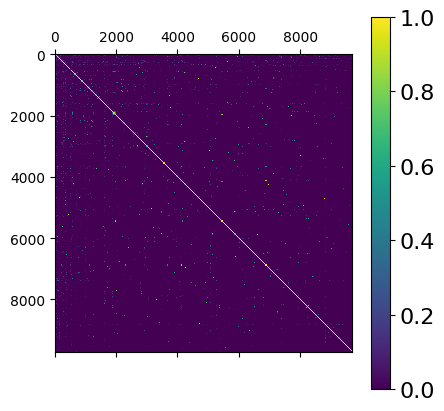

In [3]:
nm = NetworkModel()
nm.read_flows(df, window_type= 'time', sync_window_size= 20, time_scale= 'sec')
nm.fit_graph_model(method = 'cov') # cov
nm.plot_f()

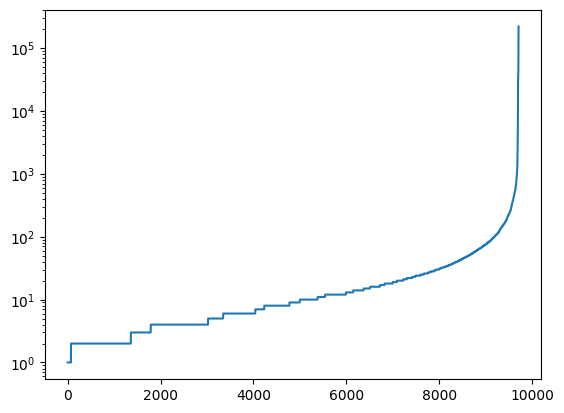

In [4]:
plt.semilogy(np.sort(nm.num_appearances))

In [5]:
ind = np.array(nm.num_appearances) > np.sort(nm.num_appearances)[::-1][1000] # freq 1000 nodes
entity_names = list(np.array(nm.names)[ind])
with open('monday_freq_1000.pickle', 'wb') as handle:
    pickle.dump(entity_names, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [24]:
victim_names = [ '192.168.10.3',
                 '192.168.10.50',
                 '192.168.10.51',
                 '192.168.10.19',
                 '192.168.10.17',
                 '192.168.10.16',
                 '192.168.10.12',
                 '192.168.10.9',
                 '192.168.10.5',
                 '192.168.10.8',
                 '192.168.10.14',
                 '192.168.10.15',
                 '192.168.10.25']

with open('victim_net.pickle', 'wb') as handle:
    pickle.dump(victim_names, handle, protocol=pickle.HIGHEST_PROTOCOL)
len(victim_names)



13

# Partitioning

In [8]:
with open('monday_freq_1000.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 
len(entity_names)

991

Conditioning number:  1039.6316558142548 
Determinant of F^T*F:  9.050495596176678e-10


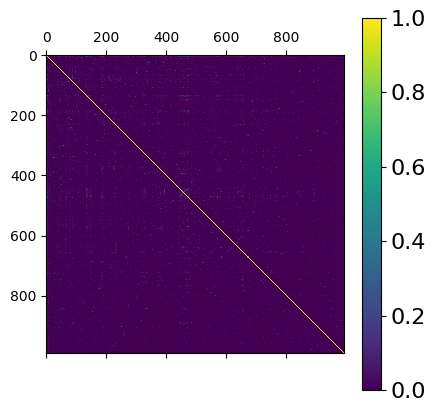

In [9]:
nm = NetworkModel()
nm.read_flows(df, entity_names=entity_names, window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')
nm.fit_graph_model(method = 'cov') # cov
nm.plot_f()

In [10]:
import importlib, src
import src.network_partitioning

importlib.reload(src.network_partitioning)
from src.network_partitioning import*

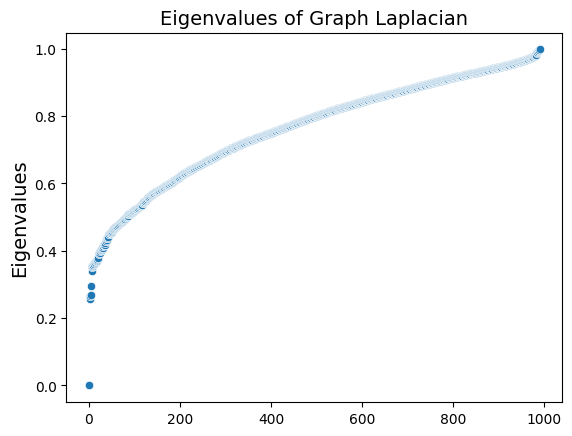

0.9991986395840328
[0.00000000e+00 3.26575198e-16 2.56500668e-01 2.64717419e-01
 2.68217379e-01 2.94309797e-01 3.38586257e-01 3.50687166e-01
 3.55155494e-01 3.56174147e-01]


In [11]:
eigvals, err = get_eig_vals_err(nm.F, nm.names)

print(err)
print(eigvals[:10])

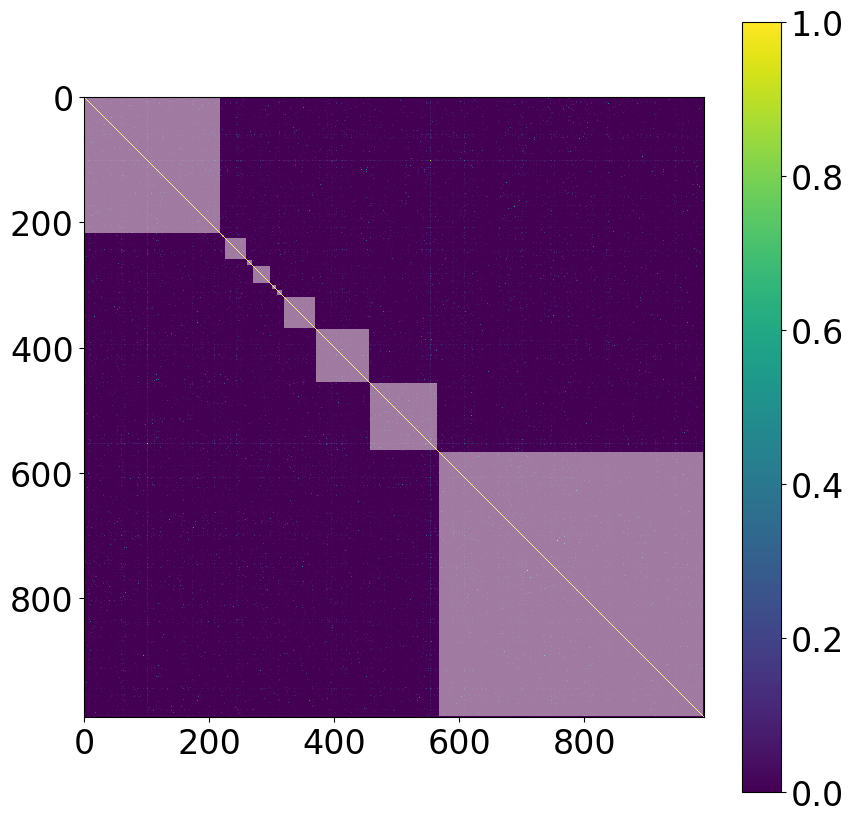

In [12]:
gr, new_labels, clusters = apply_spec_clus(nm.F, nm.names, 11, fontsize = 24) # 48
plt.rcParams.update({'font.size': 10})

25.0 % of the victim nodes are in one cluster for n= 45  clusters
Total size of the subnet:  338
16.666666666666664 % of the victim nodes are in one cluster for n= 59  clusters
Total size of the subnet:  208
8.333333333333332 % of the victim nodes are in one cluster for n= 73  clusters
Total size of the subnet:  118
8.333333333333332 % of the victim nodes are in one cluster for n= 87  clusters
Total size of the subnet:  111
8.333333333333332 % of the victim nodes are in one cluster for n= 101  clusters
Total size of the subnet:  93
8.333333333333332 % of the victim nodes are in one cluster for n= 115  clusters
Total size of the subnet:  111
8.333333333333332 % of the victim nodes are in one cluster for n= 129  clusters
Total size of the subnet:  97
8.333333333333332 % of the victim nodes are in one cluster for n= 143  clusters
Total size of the subnet:  94


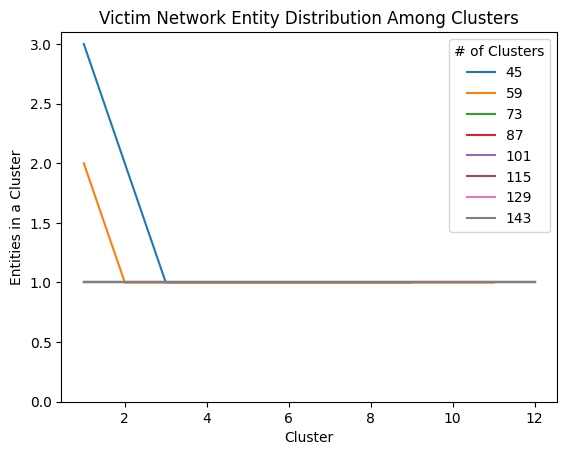

In [13]:
with open('victim_net.pickle', 'rb') as handle:
    victim_network = pickle.load(handle) 

plt.rcParams.update({'font.size': 10})
ax = plt.subplot()
num_clusters = np.arange(45, 145, 14)
for i in num_clusters:
    ggr, new_labels, clusters = apply_spec_clus(nm.F, nm.names, i, plot_bool=False)
    clus_assign = get_clus_assign(victim_network, ggr, new_labels)
    _, inv_arr, counts = np.unique(list(clus_assign.values()), return_inverse=True, return_counts= True)
    _, clus_sizes = np.unique(new_labels, return_counts= True)
    sub_net_size = np.sum(clus_sizes[inv_arr])
    print( max(counts)/len(clus_assign) * 100, '% of the victim nodes are in one cluster for n=', i, ' clusters')
    print('Total size of the subnet: ', sub_net_size)
    
    plt.plot(np.arange(1, len(counts)+1).astype(int), np.sort(counts)[::-1], label=str(i))
    
plt.ylim([0, ax.get_ylim()[1]])
plt.title('Victim Network Entity Distribution Among Clusters')
plt.xlabel('Cluster')
plt.ylabel('Entities in a Cluster')
plt.legend(title='# of Clusters')
plt.show()

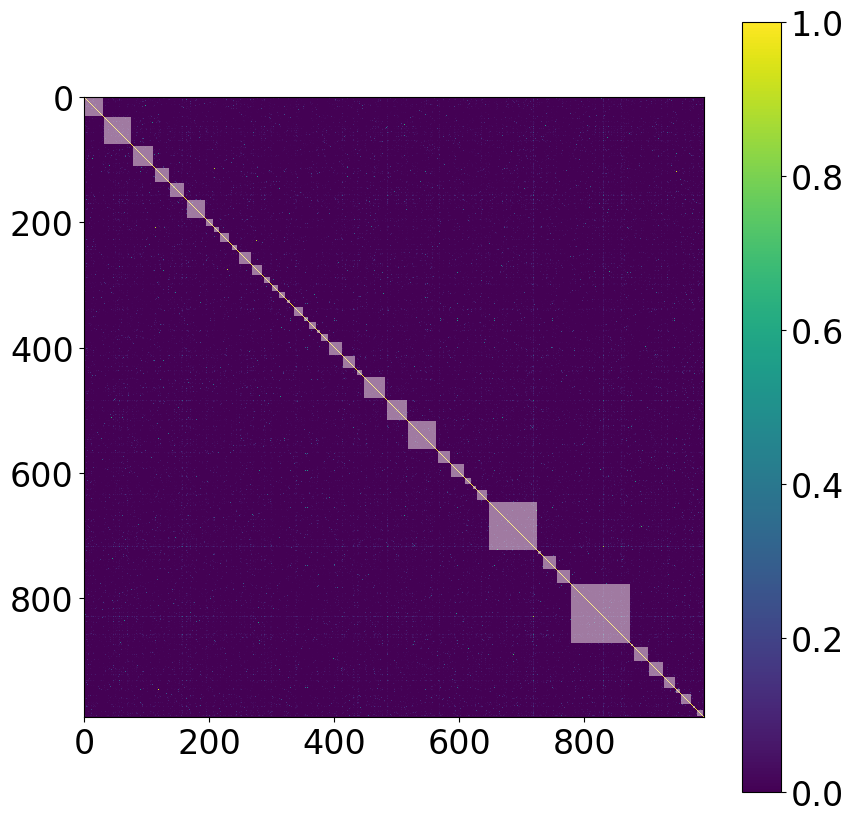

[ 1 15 29 31 34 35 39 43 44 47]


(360,)

In [18]:
gr, new_labels, clusters = apply_spec_clus(nm.F, nm.names, 48, fontsize = 24, plot_bool=True) # 48
clus_assign = get_clus_assign(victim_network, gr, new_labels)
plt.rcParams.update({'font.size': 10})

target_clusters = np.unique(list(clus_assign.values()))
print(target_clusters)
idx = np.where(np.isin(new_labels, target_clusters))
np.array(list(gr.nodes))[idx].shape

Cluster 98
Conditioning number:  1.0166005928820583 
Determinant of F^T*F:  0.9999999957083029


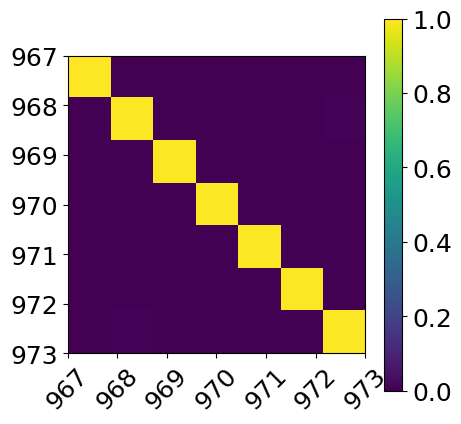

In [15]:
hr = get_graph_clus(gr, new_labels, clusters, 98, fontsize = 18) #8

In [16]:
calc_nodes = list(np.array(list(gr.nodes))[idx])
len(calc_nodes)

152

In [43]:
with open('partitioned_nodes_106.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump(calc_nodes, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [17]:
with open('partitioned_nodes.pickle', 'rb') as handle:
    calc_nodes = pickle.load(handle) 

UnpicklingError: invalid load key, '\xef'.

Conditioning number:  6.2631373693744194 
Determinant of F^T*F:  0.8338238077600261


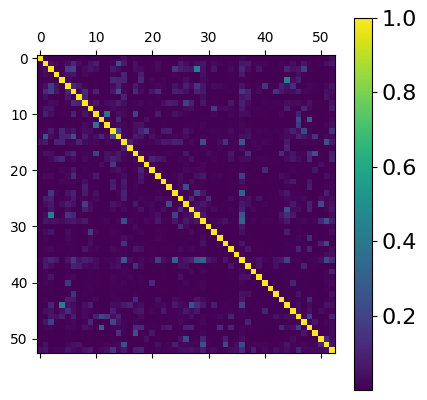

In [20]:
nm = NetworkModel()
nm.read_flows(df, entity_names=calc_nodes, conn_param='Num Packets Rec', window_type= 'time', time_scale= 'sec')
nm.fit_graph_model(method = 'cov') # cov
nm.plot_f()
plt.show()

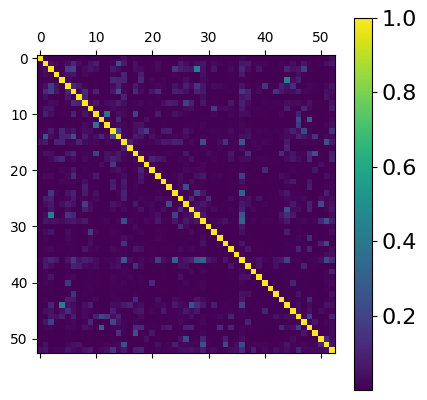

In [19]:
plt.show()

In [11]:
# Subgraphs
cond_dict = {}
nodes = np.array(list(gr.nodes))

for i, cluster in enumerate(clusters):
    ind = new_labels == cluster
    Hr = gr.subgraph(nodes[ind]).copy()
    A = nx.adjacency_matrix(Hr).todense()
    K = np.linalg.cond(A)
    d = np.linalg.det(A.T * A)
    print('Cluster '  + str(i) + '\nConditioning number: ', K, '\nDeterminant of F^T*F: ', d)
    cond_dict[cluster] = K

print(max(list(cond_dict.values())))

Cluster 0
Conditioning number:  1.1858079016188734 
Determinant of F^T*F:  0.9999509768996137
Cluster 1
Conditioning number:  1.0294947658530602 
Determinant of F^T*F:  0.9999999603357204
Cluster 2
Conditioning number:  1.1944283365259754 
Determinant of F^T*F:  0.9999504530706593
Cluster 3
Conditioning number:  1.3851247573190386 
Determinant of F^T*F:  0.9995373296610679
Cluster 4
Conditioning number:  1.187243119255009 
Determinant of F^T*F:  0.9999585950942437
Cluster 5
Conditioning number:  1.1695734942722704 
Determinant of F^T*F:  0.9999773837267613
Cluster 6
Conditioning number:  1.0050491612881451 
Determinant of F^T*F:  0.9999999999597861
Cluster 7
Conditioning number:  1.3485043225054048 
Determinant of F^T*F:  0.999732178800987
Cluster 8
Conditioning number:  1.0212322164520042 
Determinant of F^T*F:  0.9999999953208559
Cluster 9
Conditioning number:  1.372162249530943 
Determinant of F^T*F:  0.9997058902627208
Cluster 10
Conditioning number:  1.0136789643963764 
Determinan

Cluster 113
Conditioning number:  1.053100523837758 
Determinant of F^T*F:  0.9999997153098039
Cluster 114
Conditioning number:  2.024953411176656 
Determinant of F^T*F:  0.9868208454911809
Cluster 115
Conditioning number:  1.0315010585581517 
Determinant of F^T*F:  0.9999999772050826
Cluster 116
Conditioning number:  1.0123571203729012 
Determinant of F^T*F:  0.999999999434928
Cluster 117
Conditioning number:  1.014703420437529 
Determinant of F^T*F:  0.9999999990333063
Cluster 118
Conditioning number:  1.0542824552572099 
Determinant of F^T*F:  0.9999998317315469
Cluster 119
Conditioning number:  2.0729251085310247 
Determinant of F^T*F:  0.987414722614093
Cluster 120
Conditioning number:  1.0 
Determinant of F^T*F:  1.0
Cluster 121
Conditioning number:  1.0046886148748575 
Determinant of F^T*F:  0.999999999970078
Cluster 122
Conditioning number:  1.58547965659224 
Determinant of F^T*F:  0.9983250914873222
Cluster 123
Conditioning number:  1.0195170634641955 
Determinant of F^T*F:  0